In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape
from sklearn.metrics import silhouette_score
import random
import json
import joblib

In [2]:
# Seed untuk reproduksibilitas hasil
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [3]:
# Load dataset dari Stasiun Maritim Panjang BMKG Lampung
# Ganti path sesuai lokasi file dataset Anda
df = pd.read_csv(
    r"D:\draft TA\TA yang Ditawarkan Pak Meida\Dataset\krui_AndreanSyahrezi_copy.csv",
    sep=";",
    decimal=","
)

print("Shape dataset:", df.shape)
print("\nKolom:", df.columns.tolist())
print("\n5 baris pertama:")
df.head()

Shape dataset: (17544, 7)

Kolom: ['Time(UTC/GMT)', 'Hsig(m)', 'Hsig(Scale)', 'Hmax(m)', 'Hmax(Scale)', 'elev_m', 'WindSpeed(knots)']

5 baris pertama:


,Time(UTC/GMT),Hsig(m),Hsig(Scale),Hmax(m),Hmax(Scale),elev_m,WindSpeed(knots)
0,28/07/2023 00:00,0.80993,Slight,1.61966,Moderate,-0.134548,2.98668
1,28/07/2023 01:00,0.80946,Slight,1.61872,Moderate,-0.172577,3.04534
2,28/07/2023 02:00,0.80899,Slight,1.61778,Moderate,-0.172138,3.10399
3,28/07/2023 03:00,0.80852,Slight,1.61684,Moderate,-0.142076,3.16265
4,28/07/2023 04:00,0.80805,Slight,1.61591,Moderate,-0.097522,3.22131


In [4]:
# Ambil hanya kolom numerik
df = df.select_dtypes(include=[np.number])
print("Kolom numerik yang digunakan:")
print(df.columns.tolist())
print("\nStatistik deskriptif:")
df.describe()

Kolom numerik yang digunakan:
['Hsig(m)', 'Hmax(m)', 'elev_m', 'WindSpeed(knots)']

Statistik deskriptif:


,Hsig(m),Hmax(m),elev_m,WindSpeed(knots)
count,17544.000000,17544.000000,1.754400e+04,17544.000000
mean,0.895125,1.638481,8.566461e+06,3.069413
std,0.348500,0.503296,4.807387e+09,1.941410
min,0.422480,0.844960,-3.460000e+11,0.157250
25%,0.624985,1.249903,-2.077805e-01,1.800840
50%,0.764010,1.511085,-3.487211e-02,2.651320
75%,1.139202,1.943423,1.901403e-01,3.790998
max,1.964920,3.283280,4.930000e+11,14.035980


In [5]:
# Preprocessing konsisten dengan app.py preprocess_like_training()
def preprocess_like_training(df_raw):
    df = df_raw.copy()
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    # Winsorize: clip 1%-99% per kolom
    for col in df.columns:
        low  = df[col].quantile(0.01)
        high = df[col].quantile(0.99)
        df[col] = np.clip(df[col], low, high)
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()
    # Hapus kolom dengan std = 0 (tidak informatif)
    df = df.loc[:, df.std() != 0]
    return df

df = preprocess_like_training(df)
print("Shape setelah preprocessing:", df.shape)
print("Kolom:", df.columns.tolist())


Shape setelah preprocessing: (17544, 4)
Kolom: ['Hsig(m)', 'Hmax(m)', 'elev_m', 'WindSpeed(knots)']


In [6]:
# Identifikasi kolom target
elevm_column = 'elev_m'
elevm_index  = df.columns.get_loc(elevm_column)

print("Kolom fitur yang tersedia:")
for col in df.columns:
    print(f"  - '{col}'")
print(f"\nVariabel target  : '{elevm_column}'")
print(f"Indeks kolom target : {elevm_index}")
print("\n5 baris pertama:")
print(df.head())

Kolom fitur yang tersedia:
  - 'Hsig(m)'
  - 'Hmax(m)'
  - 'elev_m'
  - 'WindSpeed(knots)'

Variabel target  : 'elev_m'
Indeks kolom target : 2

5 baris pertama:
   Hsig(m)  Hmax(m)    elev_m  WindSpeed(knots)
0  0.80993  1.61966 -0.134548           2.98668
1  0.80946  1.61872 -0.172577           3.04534
2  0.80899  1.61778 -0.172138           3.10399
3  0.80852  1.61684 -0.142076           3.16265
4  0.80805  1.61591 -0.097522           3.22131


In [7]:
# Split 80:20 untuk fitting scaler — konsisten dengan app.py
# app.py load scaler dari .pkl yang di-fit dari train data ini
split_idx    = int(len(df) * 0.8)
train_raw    = df.iloc[:split_idx].values
test_raw     = df.iloc[split_idx:].values

# Scaler di-fit HANYA pada data latih (menghindari data leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw).astype(np.float32)
test_scaled  = scaler.transform(test_raw).astype(np.float32)

# Gabungkan untuk pembuatan sequences (sama seperti app.py)
data_scaled = np.concatenate([train_scaled, test_scaled], axis=0)

print(f"Data latih  : {train_scaled.shape}")
print(f"Data uji    : {test_scaled.shape}")
print(f"Gabungan    : {data_scaled.shape}")


Data latih  : (14035, 4)
Data uji    : (3509, 4)
Gabungan    : (17544, 4)


In [8]:
# Ambil nilai elev_m dari data asli (sebelum scaling) untuk clustering
elevm_values = df[[elevm_column]].values

# K-Means dengan K=2 (sesuai Bab 3.2.3)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(elevm_values)

# Sortir centroid: centroid lebih tinggi = threshold banjir rob
centers   = sorted(kmeans.cluster_centers_.flatten())
threshold = centers[1]  # Centroid tertinggi sebagai threshold banjir rob

# Transformasi threshold ke skala yang sudah dinormalisasi
dummy = np.zeros((1, df.shape[1]))
dummy[0, elevm_index] = threshold
threshold_scaled = scaler.transform(dummy)[0, elevm_index]

print("=== Hasil K-Means Clustering ===")
print(f"Cluster centers (elev_m) : {centers}")
print(f"Threshold banjir rob     : {threshold:.6f} m")
print(f"Threshold (skala normal) : {threshold_scaled:.6f}")
print(f"Jumlah data di atas threshold: {np.sum(df[elevm_column] >= threshold)}")
print(f"Proporsi banjir rob      : {np.sum(df[elevm_column] >= threshold)/len(df)*100:.2f}%")

=== Hasil K-Means Clustering ===
Cluster centers (elev_m) : [-0.18479180307169668, 0.2762758973503057]
Threshold banjir rob     : 0.276276 m
Threshold (skala normal) : 0.682850
Jumlah data di atas threshold: 3204
Proporsi banjir rob      : 18.26%


=== Evaluasi Klasterisasi ===
Silhouette Score (K-Means elev_m, K=2): 0.5943
Interpretasi: Klaster terpisah dengan baik (kualitas tinggi)


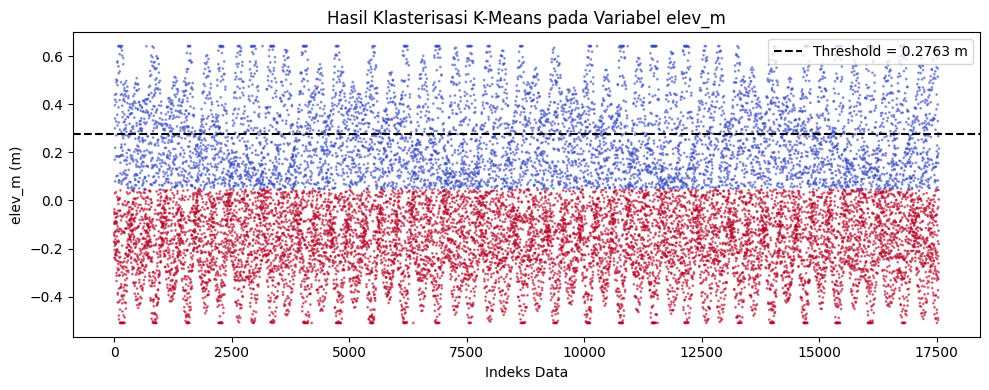

In [9]:
labels    = kmeans.labels_
sil_score = silhouette_score(elevm_values, labels)

print("=== Evaluasi Klasterisasi ===")
print(f"Silhouette Score (K-Means elev_m, K=2): {sil_score:.4f}")

if sil_score > 0.5:
    print("Interpretasi: Klaster terpisah dengan baik (kualitas tinggi)")
elif sil_score > 0.25:
    print("Interpretasi: Struktur klaster cukup")
else:
    print("Interpretasi: Klaster tumpang tindih – perlu evaluasi lebih lanjut")

# Visualisasi distribusi klaster
plt.figure(figsize=(10, 4))
plt.scatter(range(len(elevm_values)), elevm_values, c=labels, cmap='coolwarm', s=1, alpha=0.5)
plt.axhline(y=threshold, color='black', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold:.4f} m')
plt.title('Hasil Klasterisasi K-Means pada Variabel elev_m')
plt.xlabel('Indeks Data')
plt.ylabel('elev_m (m)')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
def create_sequences_multistep(data, window=48, horizon=48):
    """
    Membentuk pasangan input (X) dan target (y) untuk multi-step forecasting.
    
    Parameters:
    - data   : array data yang sudah dinormalisasi
    - window : panjang data historis sebagai input (48 timestep)
    - horizon: jumlah langkah prediksi ke depan (48 timestep)
    
    Sesuai Bab 3.2.3 (Pembentukan Data Time Series).
    """
    X, y = [], []
    for i in range(len(data) - window - horizon):
        X.append(data[i : i + window])
        y.append(data[i + window : i + window + horizon])
    return np.array(X), np.array(y)

window  = 48  # 48 jam sebelumnya sebagai input
horizon = 48  # 48 jam ke depan sebagai target

In [11]:
# Buat sequences dari data yang sudah dinormalisasi
X, y = create_sequences_multistep(data_scaled, window, horizon)

print(f"Shape X (input sequences) : {X.shape}")
print(f"Shape y (target sequences): {y.shape}")
print(f"  → {X.shape[0]} sampel, window={X.shape[1]}, fitur={X.shape[2]}")

Shape X (input sequences) : (17448, 48, 4)
Shape y (target sequences): (17448, 48, 4)
  → 17448 sampel, window=48, fitur=4


In [12]:
# Pembagian data 80:20 secara time-based (shuffle=False menjaga urutan temporal)
# Sesuai Bab 3.2.4 – Pembagian Data (Train & Test)
split_point = int(len(X) * 0.8)
X_train = X[:split_point]
X_test  = X[split_point:]
y_train = y[:split_point]
y_test  = y[split_point:]

print("=== Pembagian Data ===")
print(f"Data latih (X_train): {X_train.shape}  →  {len(X_train)} sampel")
print(f"Data uji   (X_test) : {X_test.shape}   →  {len(X_test)} sampel")

=== Pembagian Data ===
Data latih (X_train): (13958, 48, 4)  →  13958 sampel
Data uji   (X_test) : (3490, 48, 4)   →  3490 sampel


In [13]:
def is_flood_sequence(x_seq, thr_scaled, window, elevm_idx, min_streak=6):
    """
    Menentukan apakah suatu sequence mengandung kondisi banjir rob.
    Banjir rob terdeteksi jika terdapat minimal 'min_streak' timestep
    berturut-turut di atas threshold (sesuai kategori 'active').
    """
    recent  = x_seq[-window:, elevm_idx]
    exceed  = recent >= thr_scaled
    streak  = 0
    max_str = 0
    for val in exceed:
        if val:
            streak   += 1
            max_str   = max(max_str, streak)
        else:
            streak = 0
    return max_str >= min_streak

y_train_flag = np.array([
    1 if is_flood_sequence(seq, threshold_scaled, window, elevm_index) else 0
    for seq in X_train
])

counts = np.bincount(y_train_flag)
print("=== Distribusi Label pada Data Latih ===")
print(f"Calm   (0): {counts[0]} sampel ({counts[0]/len(y_train_flag)*100:.1f}%)")
print(f"Banjir (1): {counts[1]} sampel ({counts[1]/len(y_train_flag)*100:.1f}%)")

=== Distribusi Label pada Data Latih ===
Calm   (0): 11942 sampel (85.6%)
Banjir (1): 2016 sampel (14.4%)


In [14]:
def loss_combined(threshold_scaled_val, weight_flood=2.0, alpha=0.5):
    """
    Custom loss function: MSE semua fitur + penalti ringan pada elev_m saat banjir.
    Alpha dikecilkan (0.5) agar semua fitur dipelajari secara seimbang,
    tidak hanya elev_m. Sesuai kebutuhan BMKG untuk menampilkan semua fitur.
    
    Parameters:
    - threshold_scaled_val : threshold banjir rob dalam skala normalisasi
    - weight_flood         : bobot tambahan saat elev_m melebihi threshold
    - alpha                : koefisien penalti MSE pada elev_m (diperkecil agar seimbang)
    """
    def loss(y_true, y_pred):
        # MSE untuk semua fitur (bobot utama)
        mse_all = tf.reduce_mean(tf.square(y_true - y_pred))

        # MSE dengan penalti ringan pada elev_m saat melebihi threshold
        y_true_h = y_true[:, :, elevm_index]
        y_pred_h = y_pred[:, :, elevm_index]
        weights  = 1.0 + weight_flood * tf.nn.relu(y_true_h - threshold_scaled_val)
        mse_elev = tf.reduce_mean(weights * tf.square(y_true_h - y_pred_h))

        return mse_all + alpha * mse_elev
    return loss


In [15]:
# Arsitektur LSTM – sesuai Gambar 3.2 dan Tabel alat/bahan (Bab 3.3)
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window, X.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(horizon * X.shape[2], activation='linear'),
    Reshape((horizon, X.shape[2]))
])

model.compile(
    optimizer='adam',
    loss=loss_combined(threshold_scaled, weight_flood=2.0, alpha=0.5)
)

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 48, 64)            17664     
                                                                 
 dropout (Dropout)           (None, 48, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 48, 64)            33024     
                                                                 
 dropout_1 (Dropout)         (None, 48, 64)            0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 192)               6336      
                                                                 
 reshape (Reshape)           (None, 48, 4)            

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20

393/393 [==============================] - 56s 104ms/step - loss: 0.0589 - val_loss: 0.0212
Epoch 2/20
393/393 [==============================] - 38s 98ms/step - loss: 0.0109 - val_loss: 0.0119
Epoch 3/20
393/393 [==============================] - 39s 99ms/step - loss: 0.0081 - val_loss: 0.0116
Epoch 4/20
393/393 [==============================] - 42s 107ms/step - loss: 0.0074 - val_loss: 0.0101
Epoch 5/20
393/393 [==============================] - 40s 103ms/step - loss: 0.0070 - val_loss: 0.0098
Epoch 6/20
393/393 [==============================] - 38s 97ms/step - loss: 0.0066 - val_loss: 0.0107
Epoch 7/20
393/393 [==============================] - 38s 96ms/step - loss: 0.0062 - val_loss: 0.0091
Epoch 8/20
393/393 [==============================] - 38s 96ms/step - loss: 0.0060 - val_loss: 0.0095
Epoch 9/20
393/393 [==============================] - 38s 97ms/step - loss: 0.0058 - val_loss: 0.0091
Epoch 10/20
393/393 [==============================] - 38s 98ms/step - loss: 0

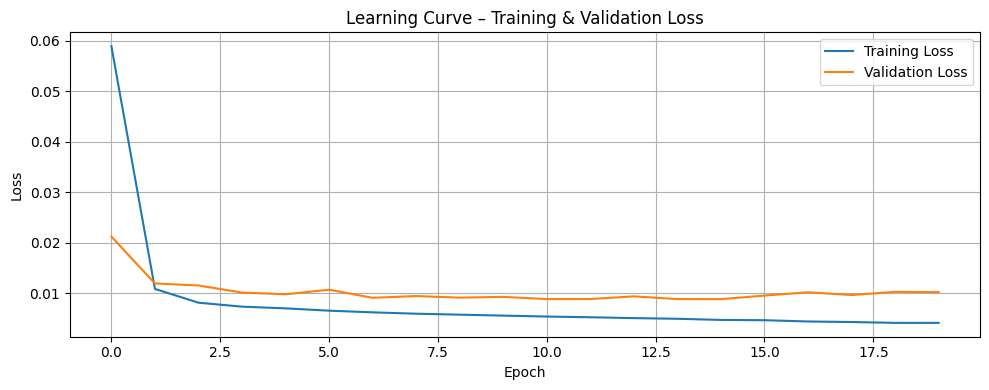


Loss terbaik (training)   : 0.004144
Loss terbaik (validation) : 0.008841


In [17]:
# Visualisasi Learning Curve – sesuai Bab 3.2.6 (Evaluasi Model Training)
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve – Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nLoss terbaik (training)   : {min(history.history['loss']):.6f}")
print(f"Loss terbaik (validation) : {min(history.history['val_loss']):.6f}")

In [18]:
# Prediksi pada data uji
y_pred = model.predict(X_test)

# Inverse scaling – kembalikan ke skala asli (satuan meter)
y_pred_inv = scaler.inverse_transform(
    y_pred.reshape(-1, X.shape[2])
).reshape(y_pred.shape)

y_test_inv = scaler.inverse_transform(
    y_test.reshape(-1, X.shape[2])
).reshape(y_test.shape)

# Ambil hanya kolom elev_m untuk evaluasi
y_pred_elevm = y_pred_inv[:, :, elevm_index]
y_test_elevm = y_test_inv[:, :, elevm_index]

print(f"Shape prediksi elev_m : {y_pred_elevm.shape}")
print(f"Shape aktual  elev_m  : {y_test_elevm.shape}")

110/110 [==============================] - 7s 33ms/step
Shape prediksi elev_m : (3490, 48)
Shape aktual  elev_m  : (3490, 48)


In [19]:
# [NO SMOOTHING] Prediksi digunakan langsung (RAW) tanpa uniform_filter1d
# y_pred_elevm tetap dari: y_pred_inv[:, :, elevm_index]
# Tujuan: membandingkan hasil dengan dan tanpa smoothing
print("Smoothing DINONAKTIFKAN — menggunakan prediksi RAW dari model")

Smoothing DINONAKTIFKAN — menggunakan prediksi RAW dari model


In [20]:
# Evaluasi RMSE dan MAE pada variabel elev_m (sesuai Tabel 3.3 skripsi)
rmse_elevm = np.sqrt(mean_squared_error(
    y_test_elevm.flatten(),
    y_pred_elevm.flatten()
))

mae_elevm = mean_absolute_error(
    y_test_elevm.flatten(),
    y_pred_elevm.flatten()
)

print("=== Evaluasi Model Testing (elev_m) ===")
print(f"RMSE : {rmse_elevm:.6f} m")
print(f"MAE  : {mae_elevm:.6f} m")

=== Evaluasi Model Testing (elev_m) ===
RMSE : 0.060729 m
MAE  : 0.044513 m


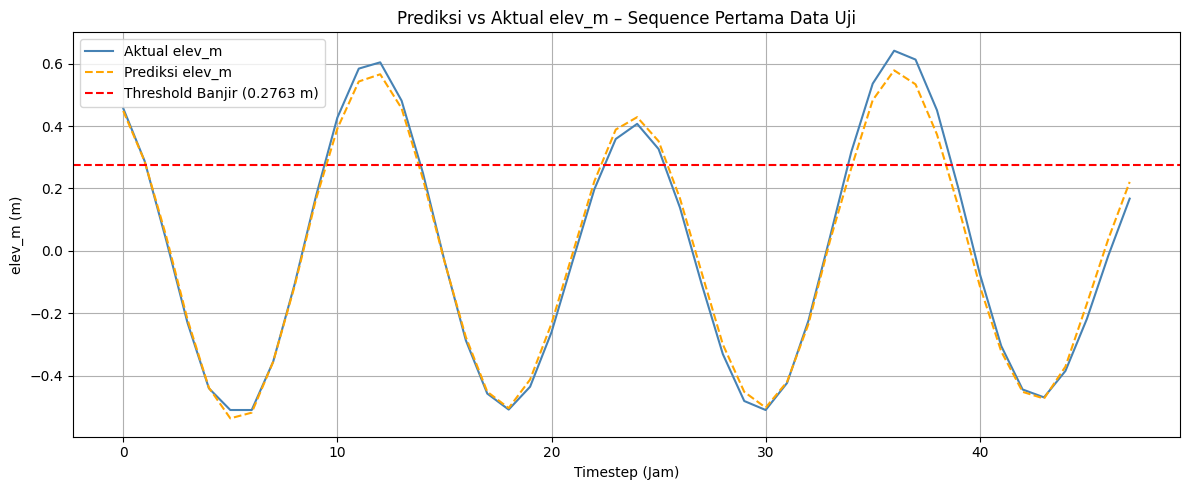

In [21]:
# Visualisasi sequence pertama pada data uji
plt.figure(figsize=(12, 5))
plt.plot(y_test_elevm[0], label='Aktual elev_m', color='steelblue')
plt.plot(y_pred_elevm[0], label='Prediksi elev_m', color='orange', linestyle='--')
plt.axhline(y=threshold, color='red', linestyle='--',
            linewidth=1.5, label=f'Threshold Banjir ({threshold:.4f} m)')
plt.title('Prediksi vs Aktual elev_m – Sequence Pertama Data Uji')
plt.xlabel('Timestep (Jam)')
plt.ylabel('elev_m (m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

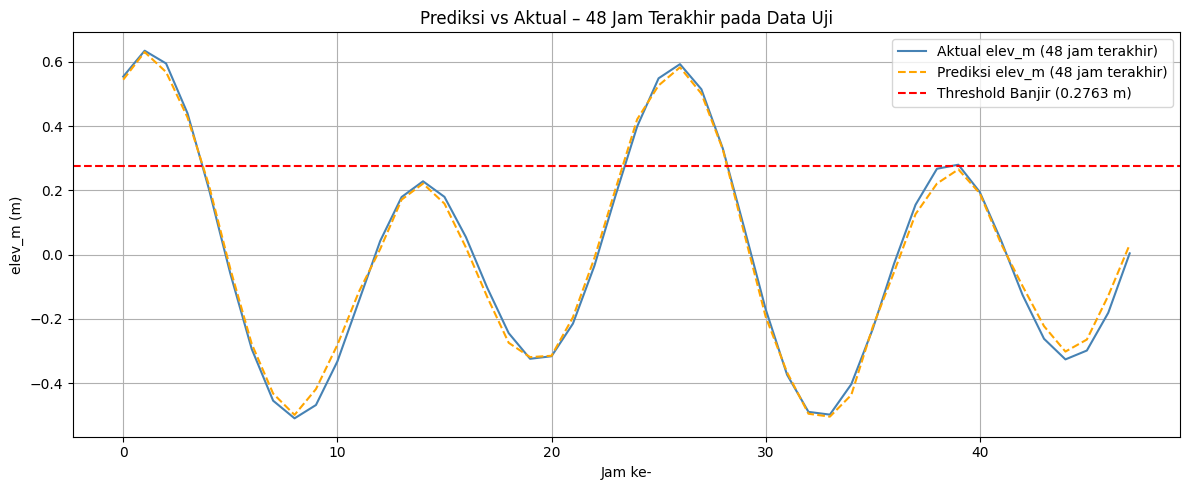

RMSE (sequence terakhir): 0.024370 m
MAE  (sequence terakhir): 0.020582 m


In [22]:
# Visualisasi 48 jam terakhir — konsisten dengan app.py (tanpa smoothing, tanpa postprocess)
actual_last48 = y_test_elevm[-1]

# app.py pakai y_pred_inv[-1] RAW (tanpa uniform_filter1d)
pred_last48 = y_pred_inv[-1][:, elevm_index]

plt.figure(figsize=(12, 5))
plt.plot(actual_last48, label='Aktual elev_m (48 jam terakhir)', color='steelblue')
plt.plot(pred_last48,   label='Prediksi elev_m (48 jam terakhir)', color='orange', linestyle='--')
plt.axhline(y=threshold, color='red', linestyle='--',
            linewidth=1.5, label=f'Threshold Banjir ({threshold:.4f} m)')
plt.title('Prediksi vs Aktual – 48 Jam Terakhir pada Data Uji')
plt.xlabel('Jam ke-')
plt.ylabel('elev_m (m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

rmse_last = np.sqrt(mean_squared_error(actual_last48, pred_last48))
mae_last  = mean_absolute_error(actual_last48, pred_last48)
print(f"RMSE (sequence terakhir): {rmse_last:.6f} m")
print(f"MAE  (sequence terakhir): {mae_last:.6f} m")


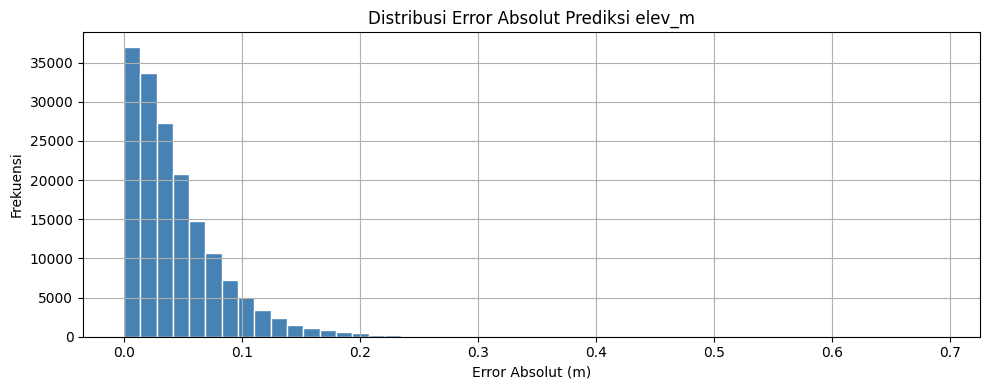

=== Analisis Error ===
10 error terbesar: [0.66831493 0.6697152  0.6699787  0.6727669  0.67392886 0.6755425
 0.68045837 0.6820759  0.6879418  0.6912044 ]
MAE saat kondisi banjir rob (banjir): 0.051011 m


In [23]:
# Analisis distribusi error prediksi
error = np.abs(y_test_elevm - y_pred_elevm)

plt.figure(figsize=(10, 4))
plt.hist(error.flatten(), bins=50, color='steelblue', edgecolor='white')
plt.title('Distribusi Error Absolut Prediksi elev_m')
plt.xlabel('Error Absolut (m)')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.tight_layout()
plt.show()

print("=== Analisis Error ===")
print(f"10 error terbesar: {np.sort(error.flatten())[-10:]}")

# MAE khusus saat kondisi banjir rob
mask_flood = y_test_elevm >= threshold
if mask_flood.sum() > 0:
    mae_flood = np.mean(np.abs(y_test_elevm[mask_flood] - y_pred_elevm[mask_flood]))
    print(f"MAE saat kondisi banjir rob (banjir): {mae_flood:.6f} m")
else:
    print("Tidak ada kondisi banjir rob pada data uji")

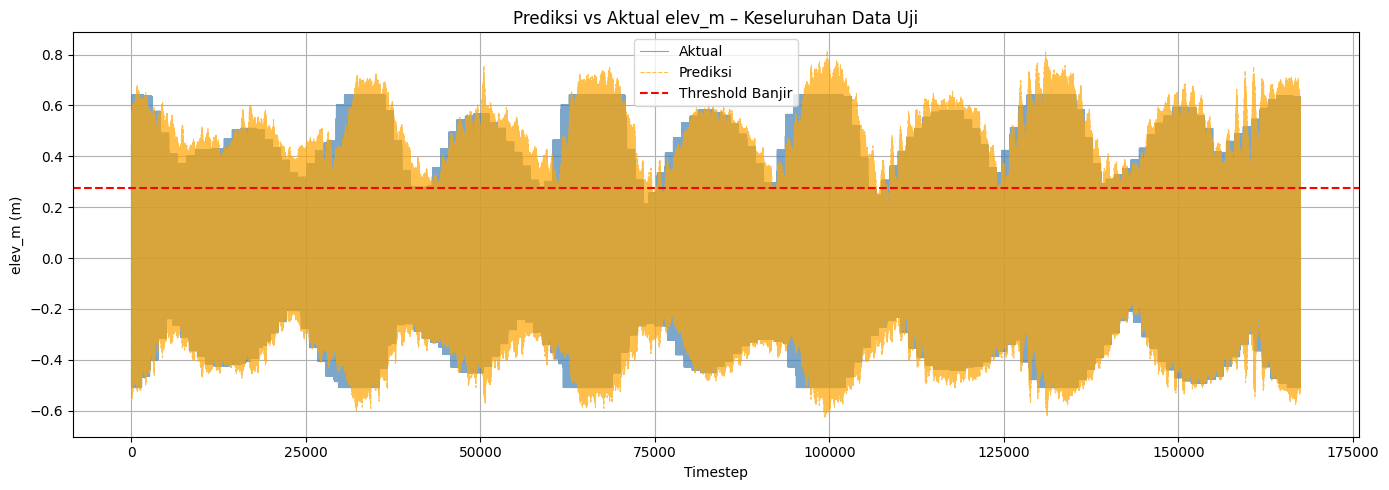

In [24]:
# Visualisasi prediksi vs aktual keseluruhan (flatten)
plt.figure(figsize=(14, 5))
plt.plot(y_test_elevm.flatten(), label='Aktual', color='steelblue', alpha=0.7, linewidth=0.8)
plt.plot(y_pred_elevm.flatten(), label='Prediksi', color='orange', alpha=0.7, linestyle='--', linewidth=0.8)
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label='Threshold Banjir')
plt.title('Prediksi vs Aktual elev_m – Keseluruhan Data Uji')
plt.xlabel('Timestep')
plt.ylabel('elev_m (m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# Ambil 48 timestep terakhir dari data yang sudah dinormalisasi
last_sequence = data_scaled[-window:].reshape(1, window, X.shape[2])

# Prediksi 48 jam ke depan
future_pred = model.predict(last_sequence)

# Inverse scaling ke skala asli
future_pred_inv = scaler.inverse_transform(
    future_pred.reshape(-1, X.shape[2])
).reshape(future_pred.shape)

future_all   = future_pred_inv[0]
future_elevm = future_all[:, elevm_index]

1/1 [==============================] - 0s 66ms/step


In [26]:
# Postprocess forecast — identik dengan app.py postprocess()
def ema(data, alpha=0.5):
    result = [data[0]]
    for i in range(1, len(data)):
        result.append(alpha * data[i] + (1 - alpha) * result[i-1])
    return np.array(result)


# last_actual dari df (sudah dipreprocess) — konsisten dengan app.py
last_actual  = df[elevm_column].iloc[-1]
offset       = last_actual - future_elevm[0]
future_elevm = future_elevm + offset

# Blend 5 timestep pertama
blend_steps = 5
for i in range(blend_steps):
    weight          = (blend_steps - i) / blend_steps
    future_elevm[i] = weight * last_actual + (1 - weight) * future_elevm[i]

# Clip minimum -2 (konsisten app.py)
future_elevm = np.clip(future_elevm, -2, None)

future_label = (future_elevm >= threshold).astype(int)


In [27]:
# Tampilkan hasil prediksi 48 jam ke depan
hasil = pd.DataFrame({
    "Jam_ke"        : np.arange(1, horizon + 1),
    "Prediksi_elev_m": np.round(future_elevm, 4),
    "Status"         : ["Banjir (Banjir Rob)" if x == 1 else "Calm (Normal)" for x in future_label]
})

print("=== HASIL PREDIKSI 48 JAM KE DEPAN ===")
print(f"Threshold banjir rob: {threshold:.6f} m")
print(hasil.to_string(index=False))

=== HASIL PREDIKSI 48 JAM KE DEPAN ===
Threshold banjir rob: 0.276276 m
 Jam_ke  Prediksi_elev_m        Status
      1           0.2153 Calm (Normal)
      2           0.2334 Calm (Normal)
      3           0.2392 Calm (Normal)
      4           0.1829 Calm (Normal)
      5           0.0254 Calm (Normal)
      6          -0.2597 Calm (Normal)
      7          -0.4650 Calm (Normal)
      8          -0.6167 Calm (Normal)
      9          -0.6477 Calm (Normal)
     10          -0.5753 Calm (Normal)
     11          -0.4329 Calm (Normal)
     12          -0.2562 Calm (Normal)
     13          -0.0835 Calm (Normal)
     14           0.0824 Calm (Normal)
     15           0.1516 Calm (Normal)
     16           0.1181 Calm (Normal)
     17          -0.0065 Calm (Normal)
     18          -0.1913 Calm (Normal)
     19          -0.3642 Calm (Normal)
     20          -0.4586 Calm (Normal)
     21          -0.5241 Calm (Normal)
     22          -0.4622 Calm (Normal)
     23          -0.3500 Calm (

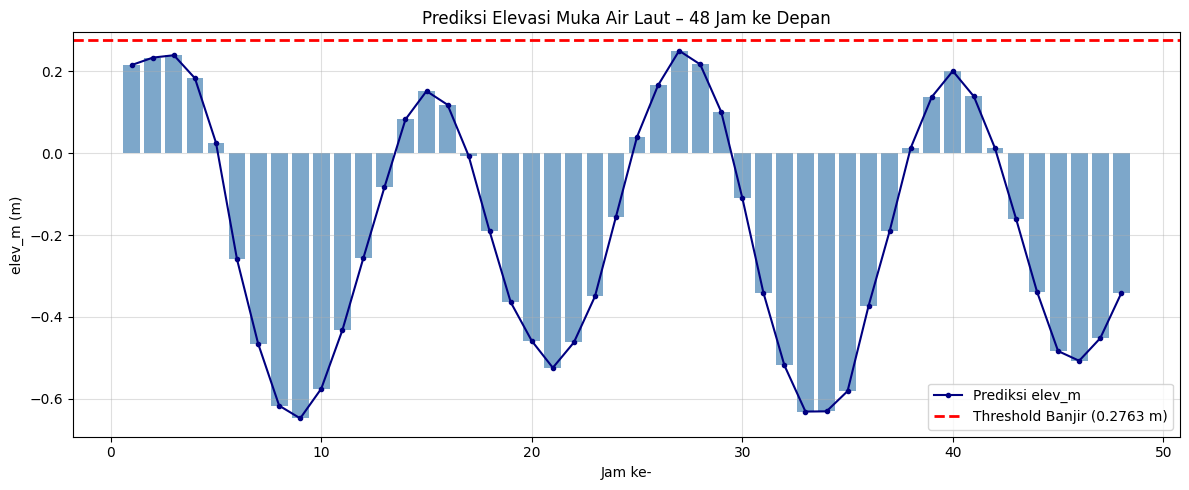


Jumlah jam dengan potensi banjir rob: 0 jam dari 48 jam
✅  Kondisi normal – tidak ada potensi banjir rob dalam 48 jam ke depan.


In [28]:
# Visualisasi prediksi 48 jam ke depan
plt.figure(figsize=(12, 5))
colors = ['red' if x == 1 else 'steelblue' for x in future_label]
plt.bar(hasil['Jam_ke'], future_elevm, color=colors, alpha=0.7, width=0.8)
plt.plot(hasil['Jam_ke'], future_elevm, marker='o', color='navy',
         linewidth=1.5, markersize=3, label='Prediksi elev_m')
plt.axhline(y=threshold, color='red', linestyle='--',
            linewidth=2, label=f'Threshold Banjir ({threshold:.4f} m)')
plt.title('Prediksi Elevasi Muka Air Laut – 48 Jam ke Depan')
plt.xlabel('Jam ke-')
plt.ylabel('elev_m (m)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

n_banjir = future_label.sum()
print(f"\nJumlah jam dengan potensi banjir rob: {n_banjir} jam dari {horizon} jam")
if n_banjir > 0:
    print("⚠️  PERINGATAN: Terdapat potensi banjir rob dalam 48 jam ke depan!")
else:
    print("✅  Kondisi normal – tidak ada potensi banjir rob dalam 48 jam ke depan.")

In [29]:
# Simpan daftar fitur dalam format JSON
features = df.columns.tolist()
with open("features.json", "w") as f:
    json.dump(features, f)
print("features.json tersimpan – fitur:", features)

features.json tersimpan – fitur: ['Hsig(m)', 'Hmax(m)', 'elev_m', 'WindSpeed(knots)']


In [30]:
# Simpan scaler Min-Max
joblib.dump(scaler, "scaler_minmax_laut.pkl")
print("scaler_minmax_laut.pkl tersimpan")

scaler_minmax_laut.pkl tersimpan


In [31]:
# Simpan model LSTM
model.save("krui.h5")
print("krui.h5 tersimpan")

krui.h5 tersimpan


c:\Users\syahr\.conda\envs\banjir_rob310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


=== RMSE & MAE per Fitur (Data Uji) ===
  Hsig(m)              RMSE: 0.213428   MAE: 0.153535
  Hmax(m)              RMSE: 0.345159   MAE: 0.246293
  elev_m               RMSE: 0.060729   MAE: 0.044513
  WindSpeed(knots)     RMSE: 2.011849   MAE: 1.434542



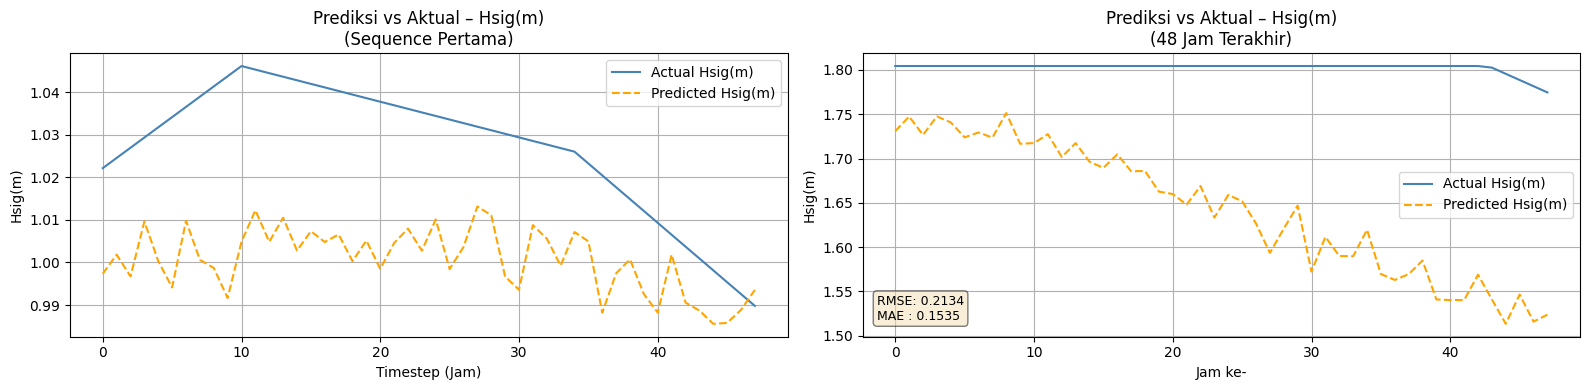

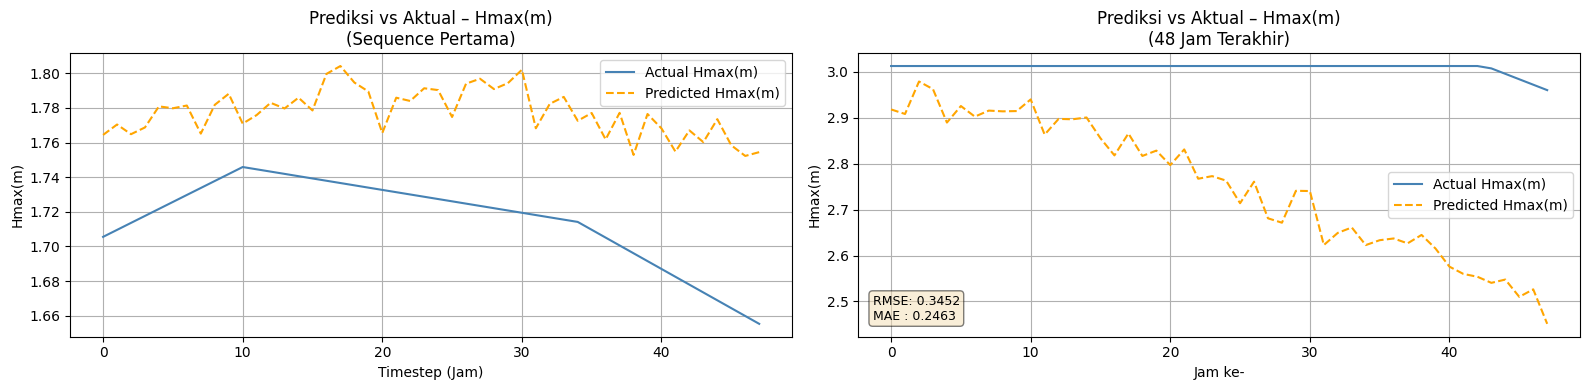

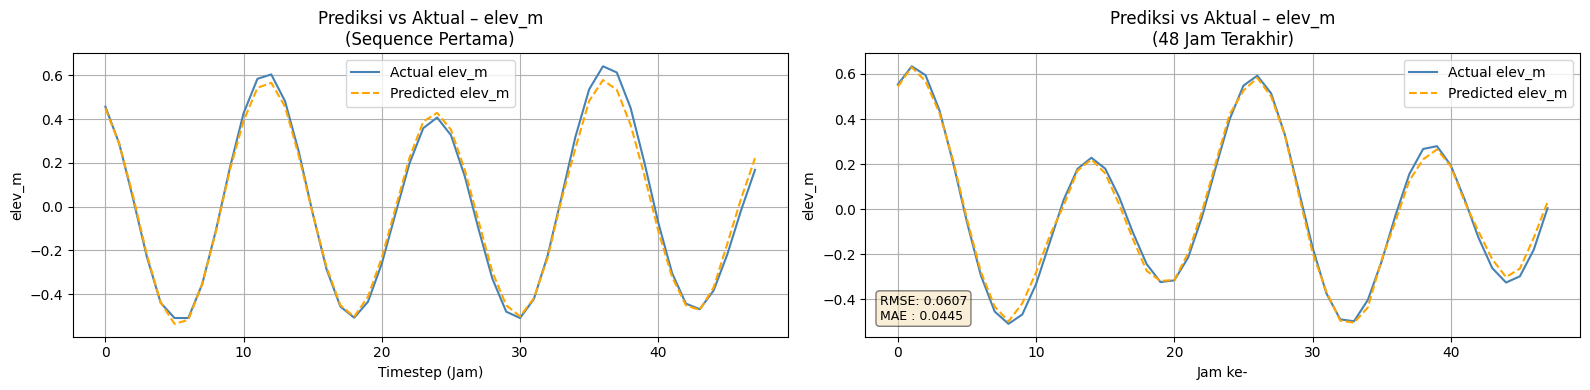

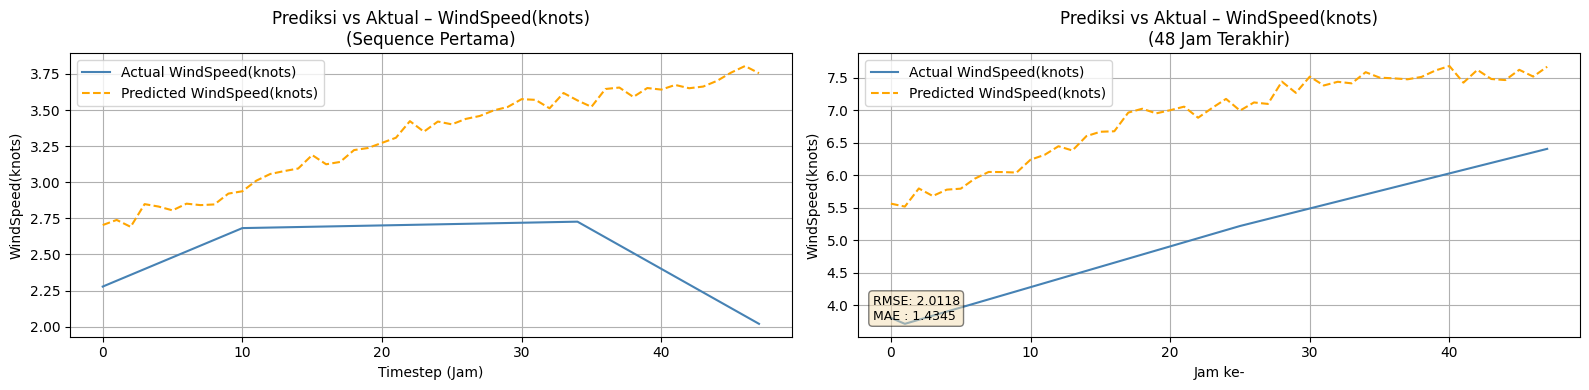

In [32]:
# Visualisasi Prediksi vs Aktual untuk Semua Fitur (sesuai permintaan BMKG)
# Menggunakan sequence pertama data uji sebagai contoh representatif

feature_names = df.columns.tolist()

print("=== RMSE & MAE per Fitur (Data Uji) ===")
rmse_per_fitur = {}
mae_per_fitur  = {}

for i, feature in enumerate(feature_names):
    actual_feat = y_test_inv[:, :, i].flatten()
    pred_feat   = y_pred_inv[:, :, i].flatten()
    rmse_f = np.sqrt(mean_squared_error(actual_feat, pred_feat))
    mae_f  = mean_absolute_error(actual_feat, pred_feat)
    rmse_per_fitur[feature] = rmse_f
    mae_per_fitur[feature]  = mae_f
    print(f"  {feature:<20} RMSE: {rmse_f:.6f}   MAE: {mae_f:.6f}")

print()

# Plot prediksi vs aktual per fitur
for i, feature in enumerate(feature_names):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Kiri: sequence pertama (contoh)
    axes[0].plot(y_test_inv[0, :, i], label=f"Actual {feature}", color="steelblue")
    axes[0].plot(y_pred_inv[0, :, i], label=f"Predicted {feature}", color="orange", linestyle="--")
    axes[0].set_title(f"Prediksi vs Aktual – {feature}\n(Sequence Pertama)")
    axes[0].set_xlabel("Timestep (Jam)")
    axes[0].set_ylabel(feature)
    axes[0].legend()
    axes[0].grid(True)

    # Kanan: 48 jam terakhir
    axes[1].plot(y_test_inv[-1, :, i], label=f"Actual {feature}", color="steelblue")
    axes[1].plot(y_pred_inv[-1, :, i], label=f"Predicted {feature}", color="orange", linestyle="--")
    axes[1].set_title(f"Prediksi vs Aktual – {feature}\n(48 Jam Terakhir)")
    axes[1].set_xlabel("Jam ke-")
    axes[1].set_ylabel(feature)
    axes[1].legend()
    axes[1].grid(True)

    # Tambahkan RMSE & MAE sebagai teks di pojok
    textstr = f"RMSE: {rmse_per_fitur[feature]:.4f}\nMAE : {mae_per_fitur[feature]:.4f}"
    axes[1].text(0.02, 0.05, textstr, transform=axes[1].transAxes,
                 fontsize=9, verticalalignment="bottom",
                 bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    plt.tight_layout()
    plt.show()


In [34]:
# Prediksi seluruh dataset (bukan hanya test)
df_raw_dt = pd.read_csv(
    r"D:\draft TA\TA yang Ditawarkan Pak Meida\Dataset\teluk_betung_AndreanSyahrezi_copy.csv",
    sep=";", decimal=","
)
df_raw_dt['datetime'] = pd.to_datetime(df_raw_dt['Time(UTC/GMT)'], dayfirst=True)

X_all, y_all = create_sequences_multistep(data_scaled, window, horizon)
y_pred_all   = model.predict(X_all)

y_pred_all_inv = scaler.inverse_transform(
    y_pred_all.reshape(-1, X.shape[2])
).reshape(y_pred_all.shape)

y_all_inv = scaler.inverse_transform(
    y_all.reshape(-1, X.shape[2])
).reshape(y_all.shape)

y_pred_all_elevm = y_pred_all_inv[:, :, elevm_index]
y_all_elevm      = y_all_inv[:, :, elevm_index]

# Bangun CSV — satu baris per timestep, ambil step pertama tiap sequence
df_index_list = df.index.tolist()
start_idx     = window  # sequence pertama mulai dari timestep ke-window

datetime_list, aktual_list, prediksi_list = [], [], []
for seq_i in range(len(y_pred_all_elevm)):
    raw_idx = df_index_list[start_idx + seq_i]
    datetime_list.append(df_raw_dt['datetime'].iloc[raw_idx])
    aktual_list.append(y_all_elevm[seq_i, 0])
    prediksi_list.append(y_pred_all_elevm[seq_i, 0])

aktual_arr   = np.array(aktual_list)
prediksi_arr = np.array(prediksi_list)

df_hasil_semua = pd.DataFrame({
    'datetime'       : datetime_list,
    'aktual_elev_m'  : aktual_arr.round(6),
    'prediksi_elev_m': prediksi_arr.round(6),
    'label_aktual'   : (aktual_arr   >= threshold).astype(int),
    'label_prediksi' : (prediksi_arr >= threshold).astype(int),
    'status_aktual'  : ['Banjir Rob' if v >= threshold else 'Normal' for v in aktual_arr],
    'status_prediksi': ['Banjir Rob' if v >= threshold else 'Normal' for v in prediksi_arr],
})

df_hasil_semua.to_csv('hasil_prediksi_semua.csv', index=False)
print(f"Tersimpan: {len(df_hasil_semua)} baris")
print(f"Dari  : {df_hasil_semua['datetime'].iloc[0]}")
print(f"Sampai: {df_hasil_semua['datetime'].iloc[-1]}")

546/546 [==============================] - 20s 37ms/step
Tersimpan: 17448 baris
Dari  : 2023-07-30 00:00:00
Sampai: 2025-07-26 22:00:00
